<a href="https://colab.research.google.com/github/sarans2223/ANN-DEEP-LEARNING/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install Required Libraries

In [2]:
!pip install -q kagglehub tensorflow gradio seaborn scikit-learn pandas matplotlib

## 2. Import Libraries and Download Dataset

In [4]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import gradio as gr

# Download dataset
path = kagglehub.dataset_download("uciml/iris")
print("Path to dataset files:", path)
print("Files in path:", os.listdir(path))

Using Colab cache for faster access to the 'iris' dataset.
Path to dataset files: /kaggle/input/iris
Files in path: ['Iris.csv', 'database.sqlite']


## 3. Load the Dataset

In [5]:
csv_file = [file for file in os.listdir(path) if file.endswith(".csv")][0]
file_path = os.path.join(path, csv_file)
df = pd.read_csv(file_path)
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 4. Understand the Dataset

In [6]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nDataset Information:")
df.info()

Shape: (150, 6)

Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data Types:
 Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## 5. Check Missing Values

In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


## 6. Check and Handle Duplicate Values

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0


## 7. Statistical Summary

In [9]:
display(df.describe())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 8. Check Target Distribution

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


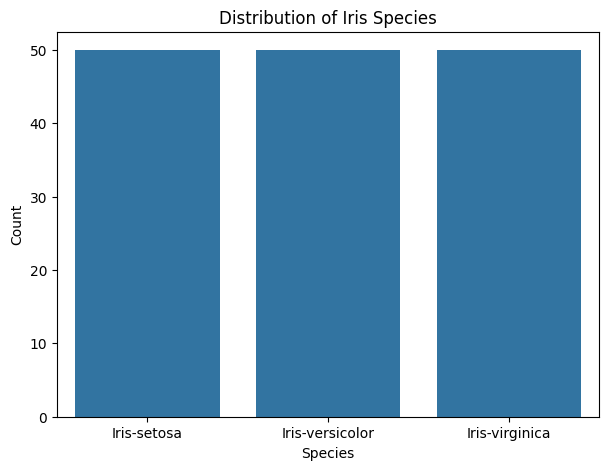

In [10]:
print(df["Species"].value_counts())
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Species")
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## 9. Exploratory Data Analysis

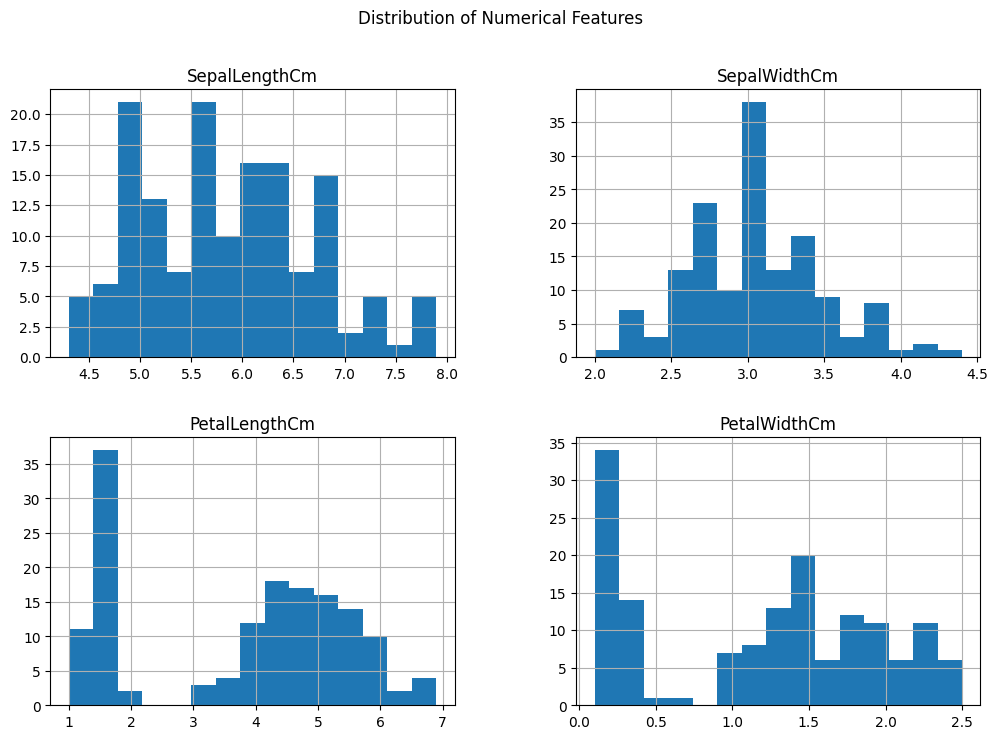

In [11]:
# Histograms
df.drop(columns=['Id'], errors='ignore').hist(figsize=(12, 8), bins=15)
plt.suptitle("Distribution of Numerical Features")
plt.show()

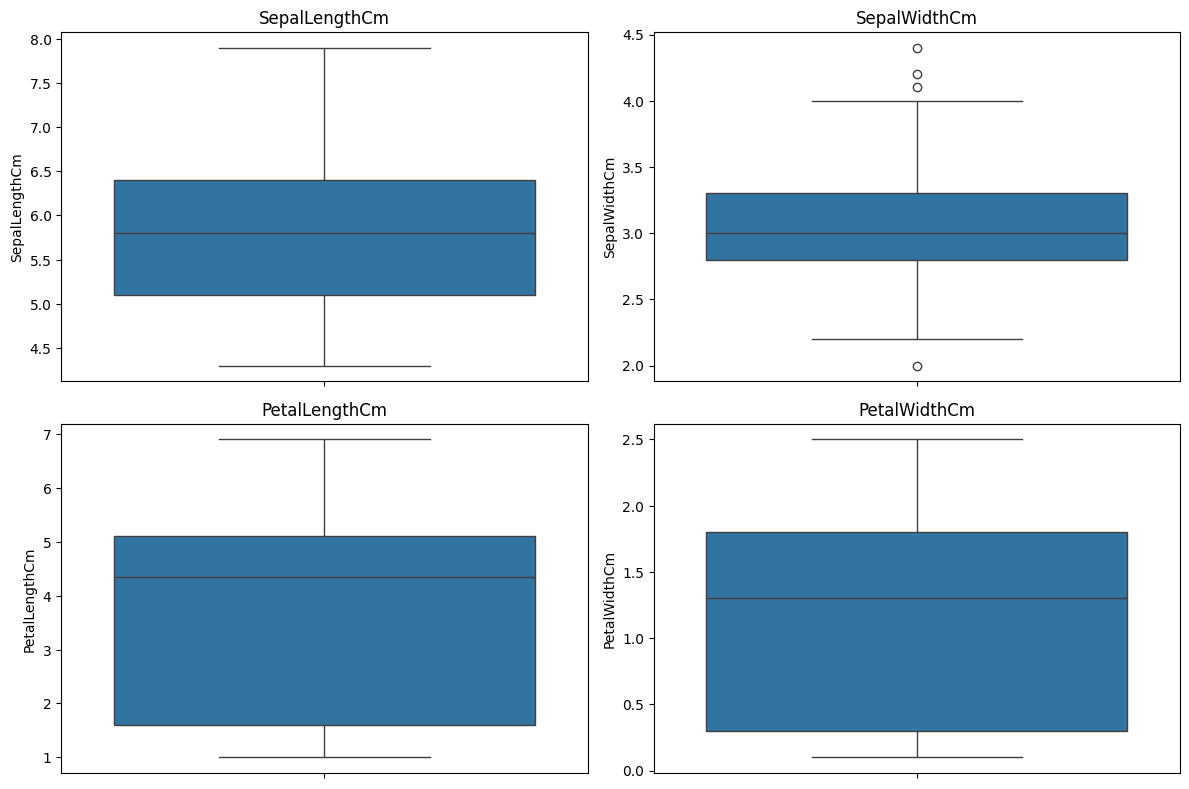

In [12]:
# Boxplots
numeric_features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, y=feature)
    plt.title(feature)
plt.tight_layout()
plt.show()

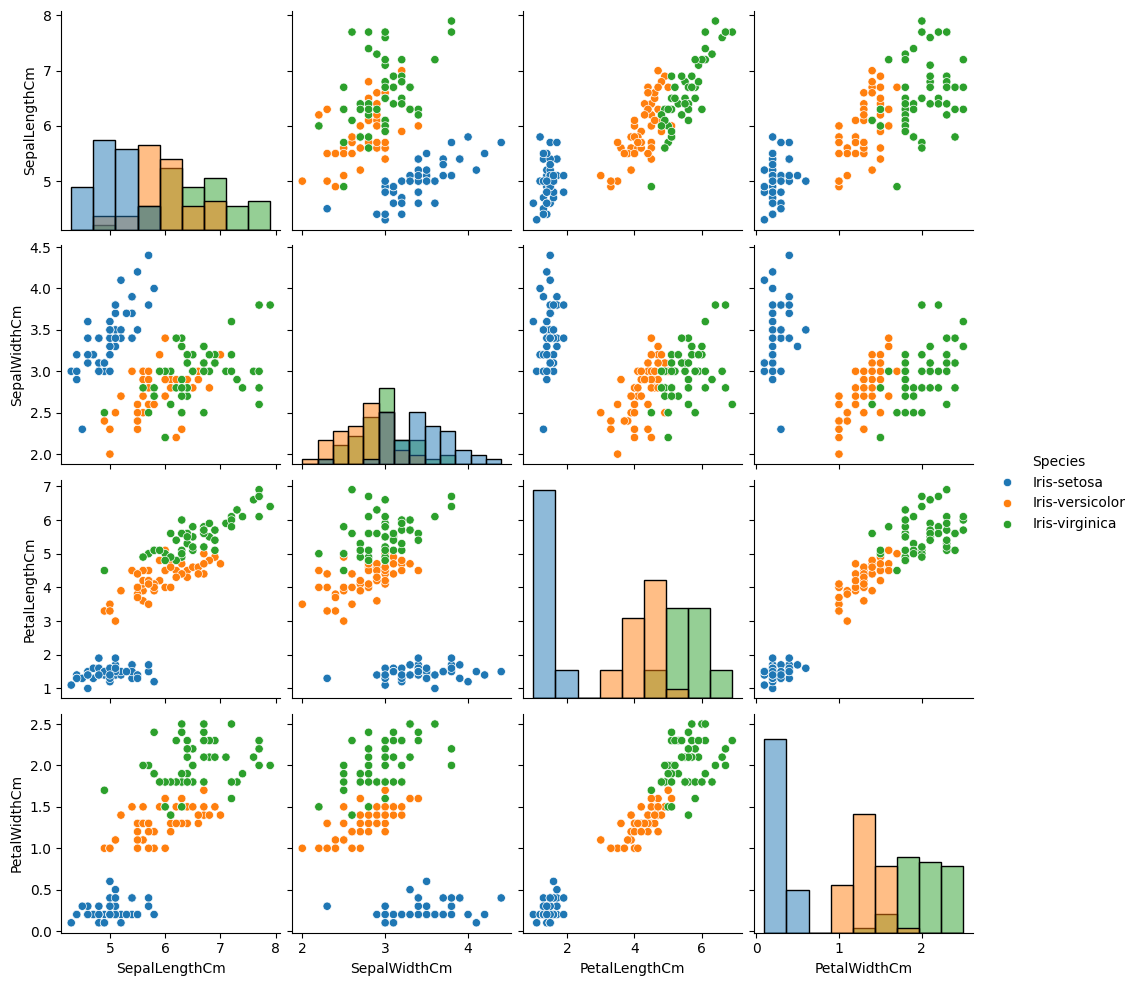

In [13]:
# Pairplot
sns.pairplot(df.drop(columns=['Id'], errors='ignore'), hue="Species", diag_kind="hist")
plt.show()

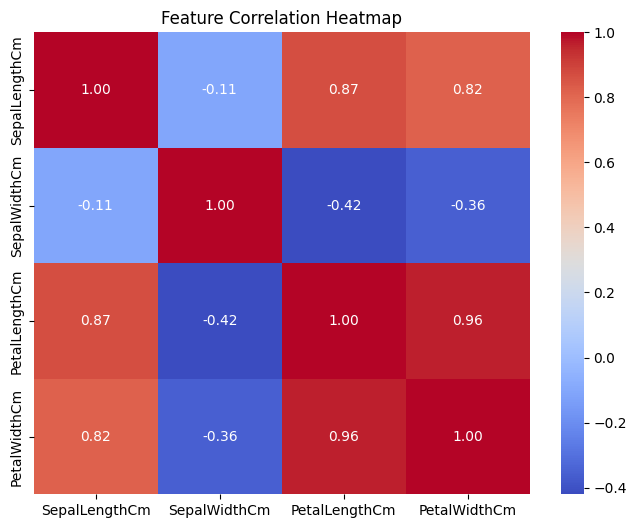

In [14]:
# Correlation Analysis
plt.figure(figsize=(8, 6))
correlation = df[numeric_features].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## 10. Feature Engineering

In [15]:
# We exclude 'Id' as it holds no predictor information
X = df[numeric_features]
y = df["Species"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded target (first 10):", y_encoded[:10])

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded target (first 10): [0 0 0 0 0 0 0 0 0 0]


## 11. Train-Test Split & Scaling

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)
print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("First 5 scaled training samples:\n", X_train_scaled[:5])

Training samples: 120 | Testing samples: 30
First 5 scaled training samples:
 [[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


## 12. Build and Compile ANN

In [17]:
model = Sequential([
    Input(shape=(4,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])
model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 13. Model Training

In [18]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6250 - loss: 1.0518 - val_accuracy: 0.7083 - val_loss: 0.9904
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6250 - loss: 1.0004 - val_accuracy: 0.6667 - val_loss: 0.9444
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6250 - loss: 0.9548 - val_accuracy: 0.7083 - val_loss: 0.9013
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6250 - loss: 0.9101 - val_accuracy: 0.6667 - val_loss: 0.8616
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6458 - loss: 0.8680 - val_accuracy: 0.6250 - val_loss: 0.8254
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7083 - loss: 0.8269 - val_accuracy: 0.6667 - val_loss: 0.7888
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7292 - loss: 0.7848 - val_accuracy: 0.7083 - val_loss: 0.7525
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7396 - loss: 0.7453 - val_accuracy: 0.

## 14. Performance Visualization & Evaluation

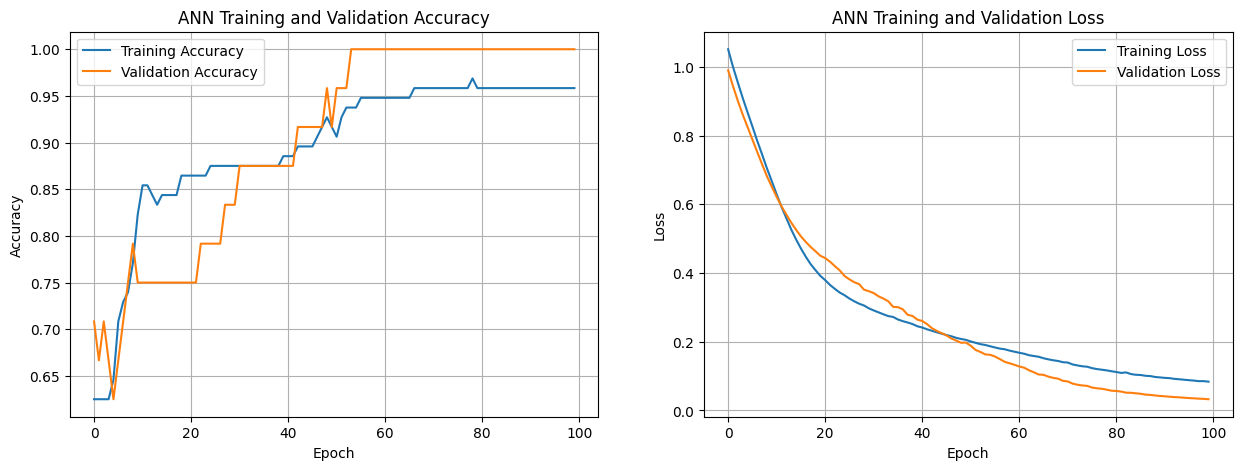

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# Accuracy plot
ax[0].plot(history.history["accuracy"], label="Training Accuracy")
ax[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
ax[0].set_title("ANN Training and Validation Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True)
# Loss plot
ax[1].plot(history.history["loss"], label="Training Loss")
ax[1].plot(history.history["val_loss"], label="Validation Loss")
ax[1].set_title("ANN Training and Validation Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(True)
plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1002 | Test Accuracy: 0.9667


## 15. Confusion Matrix & Classification Report

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


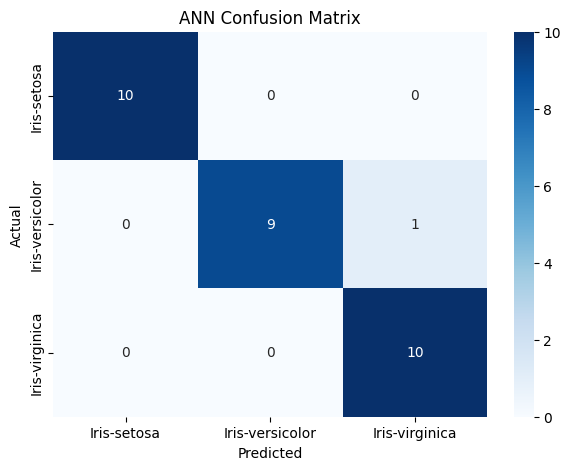

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [21]:
y_probability = model.predict(X_test_scaled)
y_pred = np.argmax(y_probability, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

## 16. Single Sample Inference

In [22]:
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
new_flower_scaled = scaler.transform(new_flower)
prediction_probability = model.predict(new_flower_scaled)
predicted_class = np.argmax(prediction_probability)
predicted_species = label_encoder.inverse_transform([predicted_class])[0]

print("Predicted Species:", predicted_species)
print("Probabilities:")
for species, prob in zip(label_encoder.classes_, prediction_probability[0]):
    print(f"  {species}: {prob:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Predicted Species: Iris-setosa
Probabilities:
  Iris-setosa: 0.9997
  Iris-versicolor: 0.0002
  Iris-virginica: 0.0000


## 17. Gradio Application

In [23]:
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    input_scaled = scaler.transform(input_data)
    probabilities = model.predict(input_scaled, verbose=0)[0]
    predicted_index = np.argmax(probabilities)
    predicted_species = label_encoder.inverse_transform([predicted_index])[0]

    result = {
        species: float(probability)
        for species, probability in zip(label_encoder.classes_, probabilities)
    }
    return predicted_species, result

demo = gr.Interface(
    fn=predict_iris,
    inputs=[
        gr.Number(label="Sepal Length (cm)", value=5.1),
        gr.Number(label="Sepal Width (cm)", value=3.5),
        gr.Number(label="Petal Length (cm)", value=1.4),
        gr.Number(label="Petal Width (cm)", value=0.2)
    ],
    outputs=[
        gr.Textbox(label="Predicted Species"),
        gr.Label(label="Prediction Probabilities")
    ],
    title="🌸 Iris Species Classification using ANN",
    description="Enter the sepal and petal measurements to predict the species of the Iris flower."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f16be56988e0e5f896.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
